# Install Base Packages

In [1]:
!pip install datasets
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Restart Runtime

# Load and Preprocess SemEval-2017 Dataset

In [1]:
from tqdm.notebook import tqdm
from datasets import load_dataset

benchmark = "SemEval-2017"
dataset = load_dataset(
    "parquet",
    data_files={
        "test":  "https://huggingface.co/datasets/midas/semeval2017/resolve/refs/convert/parquet/raw/test/0000.parquet",
        "train": "https://huggingface.co/datasets/midas/semeval2017/resolve/refs/convert/parquet/raw/train/0000.parquet",
        "validation": "https://huggingface.co/datasets/midas/semeval2017/resolve/refs/convert/parquet/raw/validation/0000.parquet"
    }
)

0000.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/320k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/65.3k [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

In [2]:
for split in dataset.keys():
    dataset[split] = dataset[split].map(lambda x: {'keyphrases': x['extractive_keyphrases'] + x['abstractive_keyphrases']})

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [3]:
for split in dataset.keys():
    dataset[split] = dataset[split].map(lambda x: {'document': ' '.join(x['document'])})

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [4]:
def remove_empty_entries_from_dataset(data):
    for split in data.keys():
        original_count = len(data[split])

        data[split] = data[split].filter(
            lambda x: (
                x['id'] and
                x['document'] and
                x['keyphrases']
            )
        )

        cleaned_count = len(data[split])

        print(f"[{split}] Before data cleaning: {original_count}")
        print(f"[{split}] After data cleaning: {cleaned_count}")

    return data

dataset = remove_empty_entries_from_dataset(dataset)

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

[test] Before data cleaning: 100
[test] After data cleaning: 100


Filter:   0%|          | 0/350 [00:00<?, ? examples/s]

[train] Before data cleaning: 350
[train] After data cleaning: 350


Filter:   0%|          | 0/50 [00:00<?, ? examples/s]

[validation] Before data cleaning: 50
[validation] After data cleaning: 50


In [5]:
dataset

DatasetDict({
    test: Dataset({
        features: ['id', 'document', 'doc_bio_tags', 'extractive_keyphrases', 'abstractive_keyphrases', 'other_metadata', 'keyphrases'],
        num_rows: 100
    })
    train: Dataset({
        features: ['id', 'document', 'doc_bio_tags', 'extractive_keyphrases', 'abstractive_keyphrases', 'other_metadata', 'keyphrases'],
        num_rows: 350
    })
    validation: Dataset({
        features: ['id', 'document', 'doc_bio_tags', 'extractive_keyphrases', 'abstractive_keyphrases', 'other_metadata', 'keyphrases'],
        num_rows: 50
    })
})

# Stem Gold Keyphrases

In [6]:
import spacy
from spacy.tokenizer import _get_regex_pattern

nlp = spacy.load("en_core_web_sm")

from spacy.lang.char_classes import ALPHA, ALPHA_LOWER, ALPHA_UPPER
from spacy.lang.char_classes import CONCAT_QUOTES, LIST_ELLIPSES, LIST_ICONS
from spacy.util import compile_infix_regex

infixes = (
    LIST_ELLIPSES
    + LIST_ICONS
    + [
        r"(?<=[0-9])[+\-\*^](?=[0-9-])",
        r"(?<=[{al}{q}])\.(?=[{au}{q}])".format(
            al=ALPHA_LOWER, au=ALPHA_UPPER, q=CONCAT_QUOTES
        ),
        r"(?<=[{a}]),(?=[{a}])".format(a=ALPHA),
        r"(?<=[{a}0-9])[:<>=/](?=[{a}])".format(a=ALPHA),
    ]
)

infix_re = compile_infix_regex(infixes)
nlp.tokenizer.infix_finditer = infix_re.finditer

In [7]:
from nltk.stem.snowball import SnowballStemmer as Stemmer

all_data = []
references = []
stemmer = Stemmer('porter')

for split in dataset.keys():
    for sample in tqdm(dataset[split]):
        all_data.append(nlp(sample["document"]))

        sample_keyphrases = []
        for keyphrase in sample["keyphrases"]:
            tokens = [token.text for token in nlp(keyphrase)]
            stems = [stemmer.stem(tok.lower()) for tok in tokens]
            sample_keyphrases.append(" ".join(stems))
        references.append(sample_keyphrases)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

# Load Prioritized Keyphrases, SNs, and their Null Models

In [8]:
import pickle

In [9]:
with open("SemEval-2017_outputs.pkl", "rb") as f:
    SemEval2017 = pickle.load(f)

In [10]:
with open("Graph_dict.pkl", "rb") as f:
    graph_dict = pickle.load(f)

In [11]:
with open("Null_Graph_dict.pkl", "rb") as f:
    null_graph_dict = pickle.load(f)

# Inject Untruths into AKE Stage

In [12]:
import networkx as nx
import copy
import numpy as np
import pandas as pd

In [13]:
G_sn = graph_dict['SemEval-2017']['KPMiner']['Cosine']
nodes = list(G_sn.nodes())

In [14]:
def evaluate_exact(top_N_candidates, references, cutoff=None):
    if cutoff is None:
        cutoff = len(references)
    cutoff = min(cutoff, len(top_N_candidates))
    P = len(set(top_N_candidates[:cutoff]) & set(references)) / len(top_N_candidates[:cutoff])
    R = len(set(top_N_candidates[:cutoff]) & set(references)) / len(references)
    F = (2 * P * R) / (P + R) if (P + R) > 0 else 0
    return (P, R, F)

def split_into_tokens(phrases):
    tokens = set()
    for phrase in phrases:
        tokens.update(phrase.split())
    return tokens

def evaluate_partial(top_N_candidates, references, cutoff=None):
    if cutoff is None:
        cutoff = len(references)
    cutoff = min(cutoff, len(top_N_candidates))

    predicted_tokens = split_into_tokens(top_N_candidates[:cutoff])
    reference_tokens = split_into_tokens(references)

    intersection = len(predicted_tokens & reference_tokens)

    P = intersection / len(predicted_tokens) if predicted_tokens else 0
    R = intersection / len(reference_tokens) if reference_tokens else 0
    F = (2 * P * R) / (P + R) if (P + R) > 0 else 0
    return (P, R, F)

def evaluate_harmonic(F1, pF1):
    return (2 * F1 * pF1) / (F1 + pF1) if (F1 + pF1) > 0 else 0

def calculate_mean_hf1(outputs_list, references_list):
    scores_harmonic = []
    for i, output in enumerate(outputs_list):
        _, _, F_exact = evaluate_exact(output, references_list[i], cutoff=None)
        _, _, F_partial = evaluate_partial(output, references_list[i], cutoff=None)
        hF1 = evaluate_harmonic(F_exact, F_partial)
        scores_harmonic.append(hF1)
    return np.mean(scores_harmonic)

In [15]:
AKE_perturbed_outputs = copy.deepcopy(SemEval2017['KeyBERT'])
AKE_perturbation_results = []

baseline_score = calculate_mean_hf1(AKE_perturbed_outputs, references)
AKE_perturbation_results.append({
    "Count": 0,
    "Target_Node": "None",
    "Noise_Label": "None",
    "Replaced_Count": 0,
    "Mean_hF1": baseline_score
})

for count, node_target in enumerate(nodes, start=1):
    noise_label = f"Frog#{count}"
    replaced_count = 0

    for doc_idx in range(len(AKE_perturbed_outputs)):
        for phrase_idx in range(len(AKE_perturbed_outputs[doc_idx])):
            if AKE_perturbed_outputs[doc_idx][phrase_idx] == node_target:
                AKE_perturbed_outputs[doc_idx][phrase_idx] = noise_label
                replaced_count += 1

    current_mean_hf1 = calculate_mean_hf1(AKE_perturbed_outputs, references)

    AKE_perturbation_results.append({
        "Count": count,
        "Target_Node": node_target,
        "Noise_Label": noise_label,
        "Replaced_Count": replaced_count,
        "Mean_hF1": current_mean_hf1
    })

In [16]:
AKE_perturbation_results_df = pd.DataFrame(AKE_perturbation_results)

In [17]:
AKE_perturbation_results_df

,Count,Target_Node,Noise_Label,Replaced_Count,Mean_hF1
0,0,None,None,0,0.484787
1,1,et al,Frog#1,0,0.484787
2,2,film,Frog#2,3,0.484633
3,3,oxid,Frog#3,7,0.483923
4,4,surfac,Frog#4,21,0.483554
5,5,particl,Frog#5,17,0.482958
6,6,data,Frog#6,5,0.482716
7,7,wave,Frog#7,3,0.482521
8,8,potenti,Frog#8,2,0.482518
9,9,magnet,Frog#9,1,0.482463


# Inject Untruths into EW Stage

In [18]:
import random

In [19]:
def calculate_fc(G, runs=1000, seed=2026):
    random.seed(seed)
    V_size = G.number_of_nodes()
    fc_list = []

    for i in range(runs):
        G_copy = G.copy()
        node_list = list(G_copy.nodes())
        random.shuffle(node_list)

        max_c2_size = -1
        fc = 0

        for step, node in enumerate(node_list):
            G_copy.remove_node(node)
            all_ccs = list(nx.connected_components(G_copy))

            if len(all_ccs) < 2:
                current_c2_size = 0

            else:
                cc_sizes = sorted([len(c) for c in all_ccs], reverse=True)
                current_c2_size = cc_sizes[1]

            if current_c2_size > max_c2_size:
                max_c2_size = current_c2_size
                fc = (step + 1) / V_size

        fc_list.append(fc)

    return np.mean(fc_list)

In [20]:
def calculate_ri(G_sn, G_null, runs=1000, seed=2026):
    fc_sn = calculate_fc(G_sn, runs=runs, seed=seed)
    fc_null = calculate_fc(G_null, runs=runs, seed=seed)

    if fc_sn > fc_null:
        ri = (fc_sn - fc_null) / (1 - fc_null)
    else:
        ri = 0

    return ri

In [21]:
G_null = null_graph_dict['SemEval-2017']['KPMiner']['Cosine']

G_sn_perturbed = G_sn.copy()
G_null_perturbed = G_null.copy()

EW_perturbation_results = []

baseline_ri = calculate_ri(G_sn_perturbed, G_null_perturbed, runs=1000, seed=2026)
baseline_c2 = (1 + baseline_ri) / 2

EW_perturbation_results.append({
    "Count": 0,
    "Removed_Node": "None",
    "Remaining_Nodes": G_sn_perturbed.number_of_nodes(),
    "RI": baseline_ri,
    "c2": baseline_c2
})

for count, node_target in enumerate(nodes, start=1):
    G_sn_perturbed.remove_node(node_target)
    G_null_perturbed.remove_node(node_target)

    current_ri = calculate_ri(G_sn_perturbed, G_null_perturbed, runs=1000, seed=2026)
    current_c2 = (1 + current_ri) / 2
    remaining_nodes_count = G_sn_perturbed.number_of_nodes()

    EW_perturbation_results.append({
        "Count": count,
        "Removed_Node": node_target,
        "Remaining_Nodes": remaining_nodes_count,
        "RI": current_ri,
        "c2": current_c2
    })

EW_pertubation_results_df = pd.DataFrame(EW_perturbation_results)

In [22]:
EW_pertubation_results_df

,Count,Removed_Node,Remaining_Nodes,RI,c2
0,0,None,50,0.311075,0.655537
1,1,et al,49,0.306801,0.653400
2,2,film,48,0.285502,0.642751
3,3,oxid,47,0.285172,0.642586
4,4,surfac,46,0.242249,0.621125
5,5,particl,45,0.231500,0.615750
6,6,data,44,0.289650,0.644825
7,7,wave,43,0.122186,0.561093
8,8,potenti,42,0.120971,0.560486
9,9,magnet,41,0.118753,0.559376


# Inject Untruths into CD Stage

### Community Detection

In [23]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 50.5 MB/s eta 0:00:00


In [24]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.1 MB/s eta 0:00:00


In [25]:
random.seed(2026)
np.random.seed(2026)
import igraph as ig
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [26]:
def leiden(G, seed=2026, resolution=1.0, weight="weight", objective="modularity", beta=0.1, n_iterations=200):
    random.seed(seed)

    nodes = sorted(G.nodes())
    node_to_index = {n: i for i, n in enumerate(nodes)}
    edges = list(G.edges(data=True))
    g = ig.Graph(n=len(G.nodes()), edges=[(node_to_index[u], node_to_index[v]) for u, v, _ in edges])
    g.es["weight"] = [similarity["weight"] for _, _, similarity in edges]

    partition = g.community_leiden(objective_function=objective, weights=g.es["weight"], resolution=resolution, beta=beta, n_iterations=n_iterations)
    communities = [set(nodes[v] for v in community) for community in partition]

    return communities

In [27]:
def tune_algorithm(G, algorithm, seed=2026, n_trials=50):
    def objective(trial):
        if algorithm == "CNM":
            communities = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
            return nx.algorithms.community.modularity(G, communities, weight="weight")

        elif algorithm == "Louvain":
            communities = list(nx.algorithms.community.louvain_communities(G, seed=seed, weight="weight"))
            return nx.algorithms.community.modularity(G, communities, weight="weight")

        elif algorithm == "Leiden":
            beta = trial.suggest_float("beta", 0.1, 10, log=True)
            communities = list(leiden(G, seed=seed, weight="weight", objective="modularity", beta=beta, n_iterations=200))
            return nx.algorithms.community.modularity(G, communities, weight="weight")

        elif algorithm == "FLPA":
            communities = list(nx.algorithms.community.fast_label_propagation_communities(G, seed=seed, weight="weight"))
            return nx.algorithms.community.modularity(G, communities, weight="weight")


    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    best_trial = study.best_trial
    return best_trial.value, best_trial.params

### Perturbation for CD

In [28]:
_, best_params = tune_algorithm(G_sn, "Leiden", seed=2026, n_trials=50)
best_beta = best_params.get("beta", 0.1)

current_communities = list(leiden(G_sn, seed=2026, weight="weight", objective="modularity", beta=best_beta))

baseline_modularity = nx.algorithms.community.modularity(G_sn, current_communities, weight="weight")

CD_perturbation_results = []
CD_perturbation_results.append({
    "Count": 0,
    "Isolated_Node": "None",
    "Num_Communities": len(current_communities),
    "Modularity": baseline_modularity
})

modified_communities = [set(c) for c in current_communities]

for count, node_target in enumerate(nodes, start=1):
    for commun in modified_communities:
        if node_target in commun:
            commun.remove(node_target)
            break

    modified_communities = [commun for commun in modified_communities if len(commun) > 0]
    modified_communities.append({node_target})

    current_modularity = nx.algorithms.community.modularity(G_sn, modified_communities, weight="weight")
    if current_modularity < 0:
        current_modularity = 0

    CD_perturbation_results.append({
        "Count": count,
        "Isolated_Node": node_target,
        "Num_Communities": len(modified_communities),
        "Modularity": current_modularity
    })

CD_perturbation_results_df = pd.DataFrame(CD_perturbation_results)

# Build Weighted Sums

In [29]:
AKE_transient_df = AKE_perturbation_results_df[['Count', 'Mean_hF1']].rename(columns={'Mean_hF1': 'c1'})
EW_transient_df = EW_pertubation_results_df[['Count', 'c2']]
CD_transient_df = CD_perturbation_results_df[['Count', 'Modularity']].rename(columns={'Modularity': 'c3'})

Perturbation_summary_df = pd.merge(AKE_transient_df, EW_transient_df, on='Count', how='inner')
Perturbation_summary_df = pd.merge(Perturbation_summary_df, CD_transient_df, on='Count', how='inner')
Perturbation_summary_df = Perturbation_summary_df.sort_values('Count').reset_index(drop=True)

In [30]:
Perturbation_summary_df['Our J'] = Perturbation_summary_df['c1'] * Perturbation_summary_df['c2'] * Perturbation_summary_df['c3']

In [31]:
Perturbation_summary_df['Arithmetic Mean'] = (Perturbation_summary_df['c1'] + Perturbation_summary_df['c2'] + Perturbation_summary_df['c3']) / 3

In [32]:
with open("RESULTING_DATAFRAME.pkl", "rb") as f:
    RESULTING_DATAFRAME = pickle.load(f)

In [33]:
RESULTING_DATAFRAME_NUS = RESULTING_DATAFRAME[RESULTING_DATAFRAME['Dataset'] == 'SemEval-2017']

var_hF1 = RESULTING_DATAFRAME_NUS['hF1'].var(ddof=1)
var_C2 = RESULTING_DATAFRAME_NUS['C2'].var(ddof=1)
var_Modularity = RESULTING_DATAFRAME_NUS['Modularity'].var(ddof=1)

variances = np.array([var_hF1, var_C2, var_Modularity])

inverse_variances = 1.0 / (variances)
ivw_weights = (inverse_variances / np.sum(inverse_variances)).tolist()

w1, w2, w3 = ivw_weights

Perturbation_summary_df['IVW'] = (
    w1 * Perturbation_summary_df['c1'] +
    w2 * Perturbation_summary_df['c2'] +
    w3 * Perturbation_summary_df['c3']
)

In [34]:
std_hF1 = RESULTING_DATAFRAME_NUS['hF1'].std(ddof=1)
std_C2 = RESULTING_DATAFRAME_NUS['C2'].std(ddof=1)
std_Modularity = RESULTING_DATAFRAME_NUS['Modularity'].std(ddof=1)

std_devs = np.array([std_hF1, std_C2, std_Modularity])

spearman_corr_matrix = RESULTING_DATAFRAME_NUS[['hF1', 'C2', 'Modularity']].corr(method='spearman').values

conflict_amounts = np.sum(1.0 - spearman_corr_matrix, axis=1)
C_info = std_devs * conflict_amounts
critic_weights = (C_info / np.sum(C_info)).tolist()

w1, w2, w3 = critic_weights

Perturbation_summary_df['CRITIC'] = (
    w1 * Perturbation_summary_df['c1'] +
    w2 * Perturbation_summary_df['c2'] +
    w3 * Perturbation_summary_df['c3']
)

In [35]:
Perturbation_summary_df

,Count,c1,c2,c3,Our J,Arithmetic Mean,IVW,CRITIC
0,0,0.484787,0.655537,0.562503,0.178761,0.567609,0.618154,0.545829
1,1,0.484787,0.653400,0.536432,0.169920,0.558206,0.614226,0.533785
2,2,0.484633,0.642751,0.520619,0.162172,0.549334,0.604895,0.524988
3,3,0.483923,0.642586,0.505715,0.157258,0.544075,0.603311,0.517981
4,4,0.483554,0.621125,0.487376,0.146382,0.530685,0.585714,0.506310
5,5,0.482958,0.615750,0.464701,0.138193,0.521136,0.579594,0.495059
6,6,0.482716,0.644825,0.458835,0.142821,0.528792,0.600544,0.496773
7,7,0.482521,0.561093,0.440038,0.119135,0.494550,0.536849,0.475442
8,8,0.482518,0.560486,0.402162,0.108762,0.481722,0.532989,0.458324
9,9,0.482463,0.559376,0.399033,0.107690,0.480291,0.531877,0.456726


# Analysis

In [36]:
target_functions = ['Our J', 'Arithmetic Mean', 'IVW', 'CRITIC']
function_comparison = []

for col in target_functions:
    y = Perturbation_summary_df[col].values
    x = Perturbation_summary_df['Count'].values

    drop_rate = ((y[0] - y[-1]) / y[0]) * 100

    function_comparison.append({
        "Objective Function": col,
        "Relative Drop Rate (%)": drop_rate
    })

function_comparison_df = pd.DataFrame(function_comparison)

In [37]:
function_comparison_df

,Objective Function,Relative Drop Rate (%)
0,Our J,100.000000
1,Arithmetic Mean,42.613833
2,IVW,27.021139
3,CRITIC,51.230420


In [38]:
import matplotlib.pyplot as plt

target_cols = ["Our J", "Arithmetic Mean", "IVW", "CRITIC"]
Normalized_Ps_df = Perturbation_summary_df.copy()

for col in target_cols:
    Normalized_Ps_df[col] = Normalized_Ps_df[col] / Normalized_Ps_df[col].iloc[0]

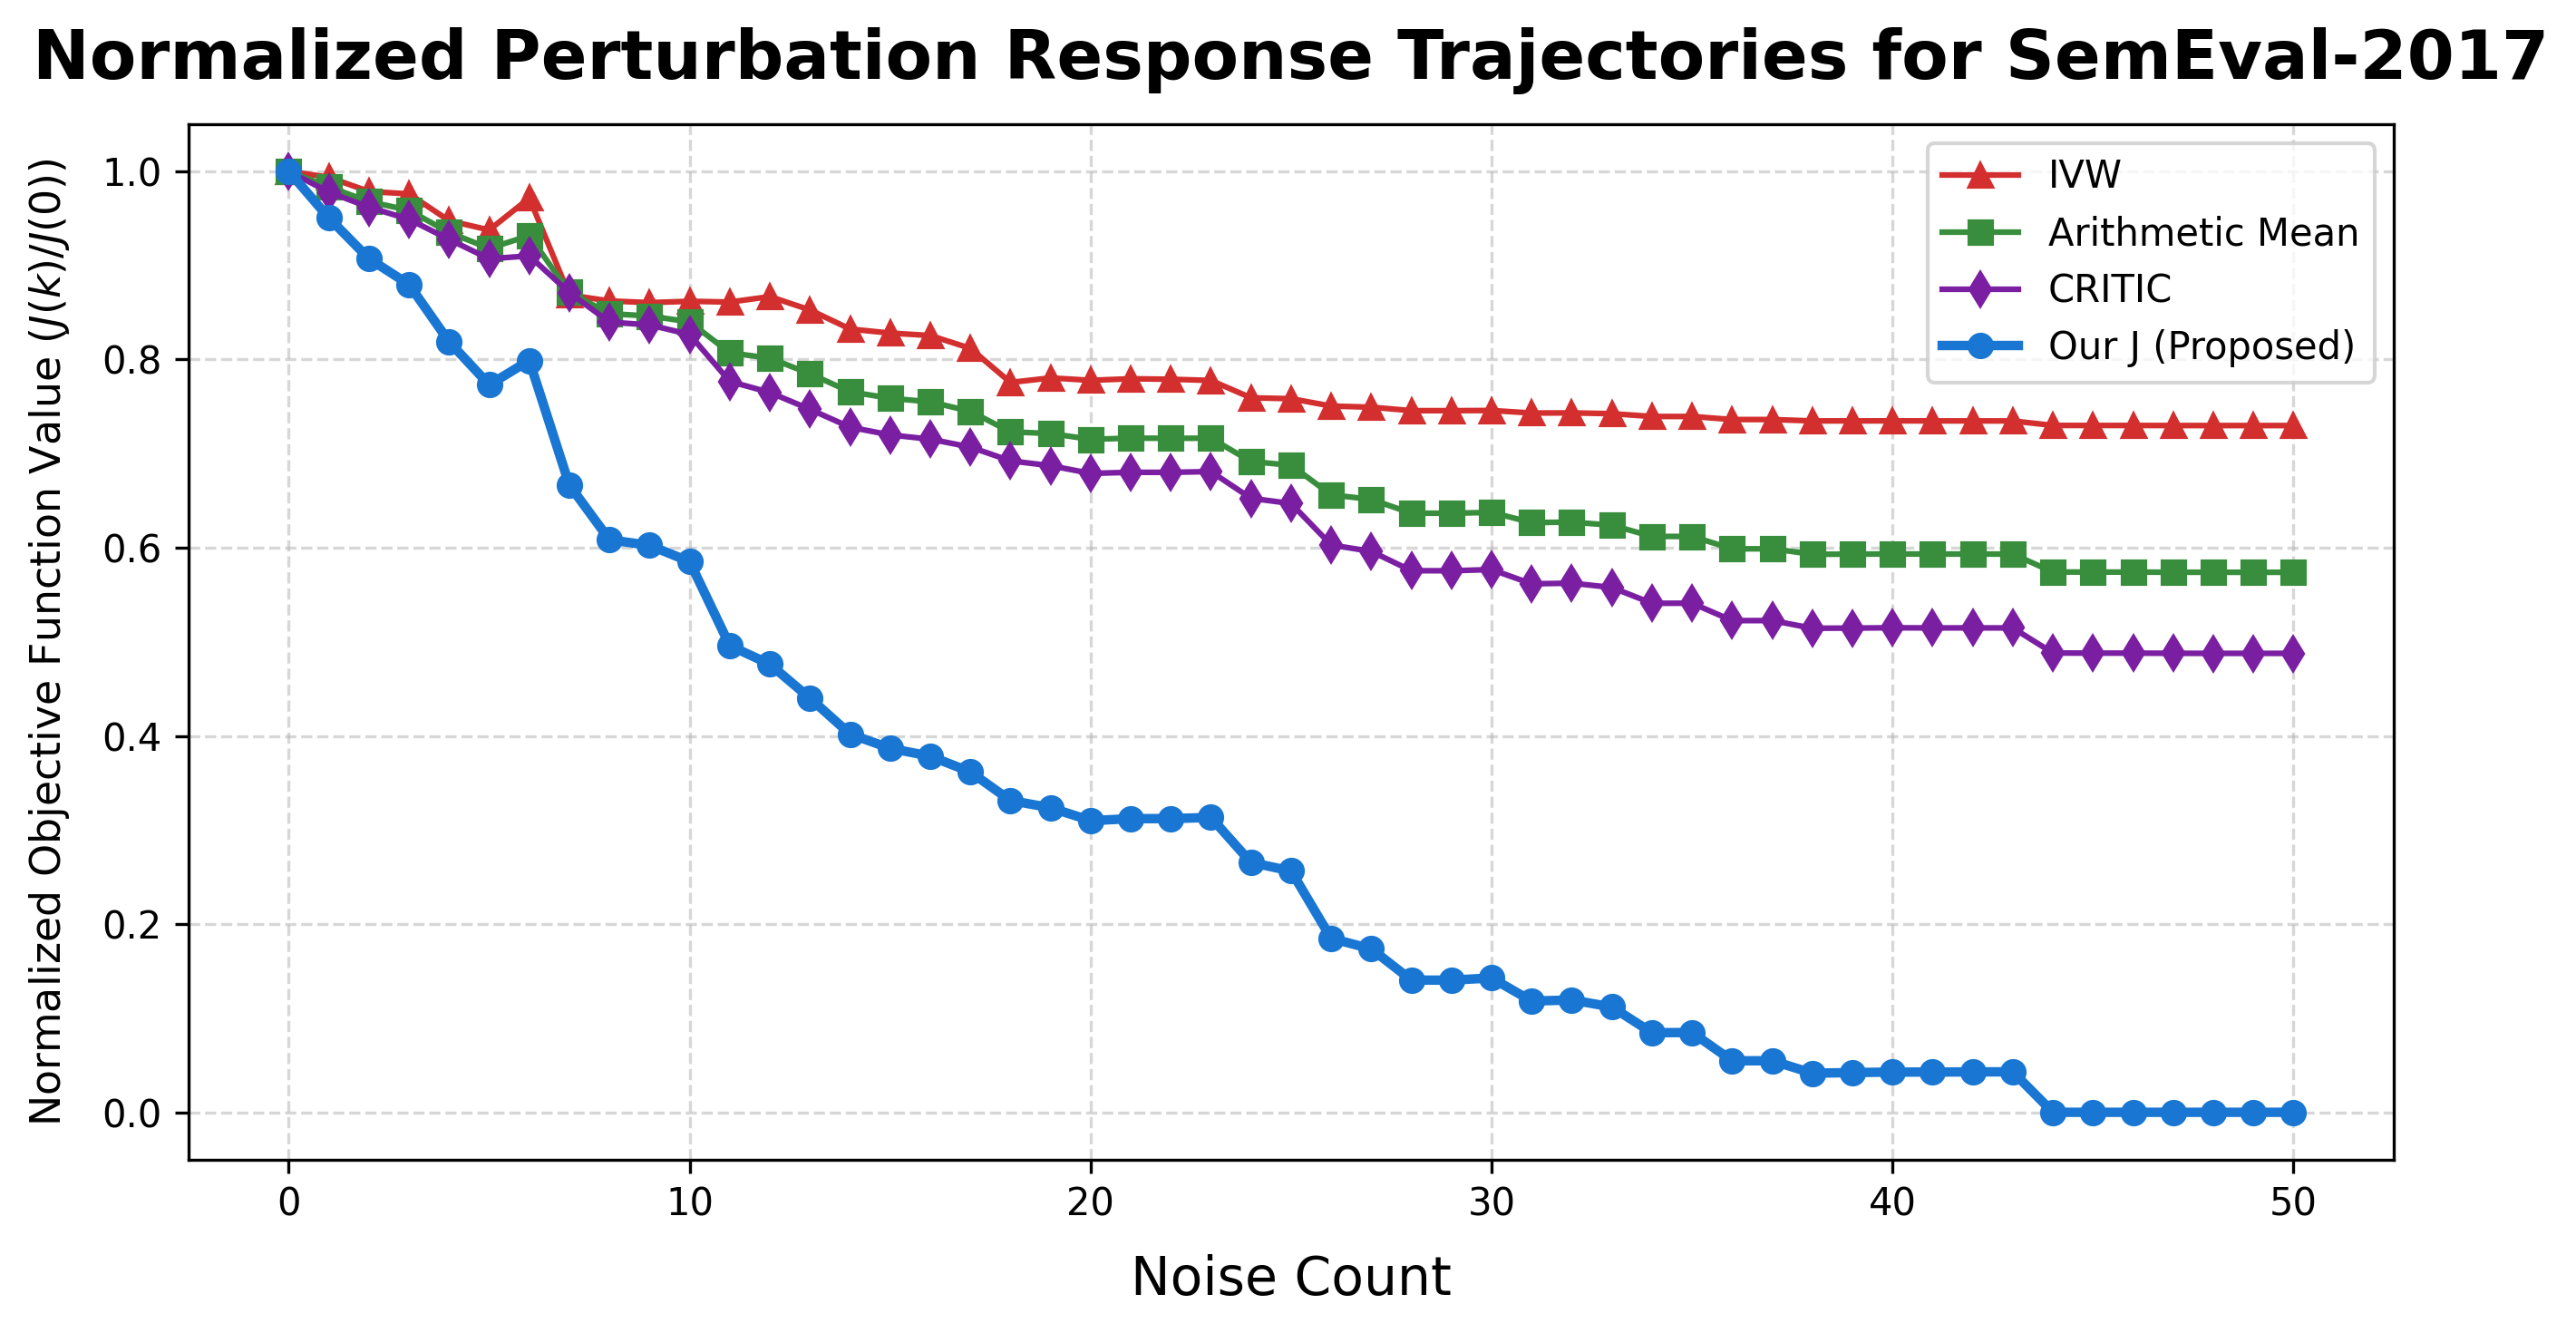

In [39]:
plt.figure(figsize=(9, 5), dpi=300)

target_cols = ["IVW", "Arithmetic Mean", "CRITIC", "Our J"]

styles = {
    "Arithmetic Mean": {"color": "#388E3C", "marker": "s", "linewidth": 1.5, "label": "Arithmetic Mean"},
    "IVW": {"color": "#D32F2F", "marker": "^", "linewidth": 1.5, "label": "IVW"},
    "CRITIC": {"color": "#7B1FA2", "marker": "d", "linewidth": 1.5, "label": "CRITIC"},
    "Our J": {"color": "#1976D2", "marker": "o", "linewidth": 2.5, "label": "Our J (Proposed)"}
}

for col in target_cols:
    plt.plot(
        Normalized_Ps_df["Count"],
        Normalized_Ps_df[col],
        color=styles[col]["color"],
        marker=styles[col]["marker"],
        linewidth=styles[col]["linewidth"],
        label=styles[col]["label"]
    )

plt.title("Normalized Perturbation Response Trajectories for SemEval-2017", fontsize=18, fontweight='bold', pad=12)
plt.xlabel("Noise Count", fontsize=14, labelpad=8)
plt.ylabel("Normalized Objective Function Value ($J(k) / J(0)$)", fontsize=11, labelpad=8)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")
plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [40]:
stage_cols = {
    "AKE (c1)": Perturbation_summary_df['c1'],
    "EW (c2)": Perturbation_summary_df['c2'],
    "CD (c3)": Perturbation_summary_df['c3'],
    "J_without_AKE (c2*c3)": Perturbation_summary_df['c2'] * Perturbation_summary_df['c3'],
    "J_without_EW (c1*c3)": Perturbation_summary_df['c1'] * Perturbation_summary_df['c3'],
    "J_without_CD (c1*c2)": Perturbation_summary_df['c1'] * Perturbation_summary_df['c2'],
    "Our J (c1*c2*c3)": Perturbation_summary_df['Our J']
}

stage_analysis = []

for name, series in stage_cols.items():
    y = series.values
    drop_rate = ((y[0] - y[-1]) / y[0]) * 100

    stage_analysis.append({
        "Stage or Component": name,
        "Relative Drop Rate (%)": drop_rate
    })

stage_analysis_df = pd.DataFrame(stage_analysis)

In [41]:
stage_analysis_df

,Stage or Component,Relative Drop Rate (%)
0,AKE (c1),1.567592
1,EW (c2),23.726701
2,CD (c3),100.000000
3,J_without_AKE (c2*c3),100.000000
4,J_without_EW (c1*c3),100.000000
5,J_without_CD (c1*c2),24.922355
6,Our J (c1*c2*c3),100.000000


# Extract Requirements

In [43]:
!pip freeze > Perturbation_Analysis_SemEval-2017.txt